<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Wee5_Assignment/Cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import pandas as pd

In [3]:
corpus = [
    "Tokopedia dan Gojek resmi merger membentuk GoTo, menjadi startup terbesar di Indonesia dengan valuasi miliaran dolar.",
    "GoTo Group mencatatkan pertumbuhan pengguna aktif yang signifikan setelah merger Tokopedia dan Gojek pada 2021.",
    "Startup teknologi Indonesia seperti GoTo dan Traveloka terus ekspansi ke pasar Asia Tenggara untuk meningkatkan valuasi."
]

vec = CountVectorizer(vocabulary=['goto', 'merger'])
X = vec.fit_transform(corpus)

In [4]:
cos_sim = cosine_similarity(X[0:1], X)

result = pd.DataFrame(X.toarray(), columns=['GoTo', 'Merger'])
result['Cosine Sim to Doc 0'] = cos_sim.flatten()
result

,GoTo,Merger,Cosine Sim to Doc 0
0,1,1,1.000000
1,1,1,1.000000
2,1,0,0.707107


In [5]:
tf = pd.DataFrame(
    [Counter(doc.split()) for doc in corpus]
).fillna(0)
tf

,Tokopedia,dan,Gojek,resmi,merger,membentuk,"GoTo,",menjadi,startup,terbesar,...,Traveloka,terus,ekspansi,ke,pasar,Asia,Tenggara,untuk,meningkatkan,valuasi.
0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


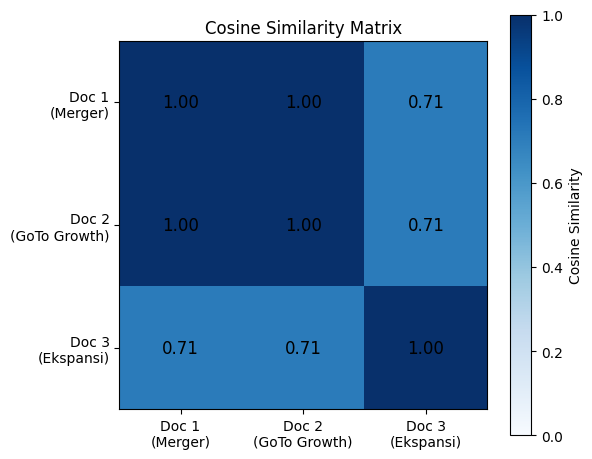

In [6]:
import matplotlib.pyplot as plt
import numpy as np

vec_full = CountVectorizer(vocabulary=['goto', 'merger'])
X_full = vec_full.fit_transform(corpus)
sim_matrix = cosine_similarity(X_full)

labels = ['Doc 1\n(Merger)', 'Doc 2\n(GoTo Growth)', 'Doc 3\n(Ekspansi)']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center', fontsize=12)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_title('Cosine Similarity Matrix')
plt.tight_layout()
plt.show()

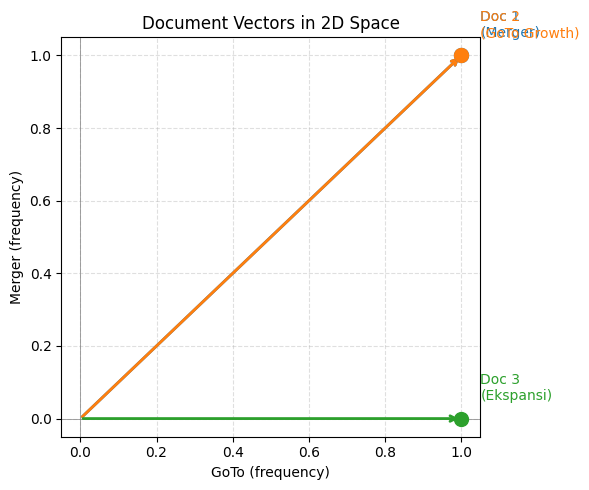

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

points = X_full.toarray()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (point, label) in enumerate(zip(points, labels)):
    ax.annotate('', xy=point, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.scatter(*point, color=colors[i], s=100, zorder=5)
    ax.text(point[0] + 0.05, point[1] + 0.05, label, fontsize=10, color=colors[i])

ax.set_xlabel('GoTo (frequency)')
ax.set_ylabel('Merger (frequency)')
ax.set_title('Document Vectors in 2D Space')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()